In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "heart_disease_clean.csv"
)

if not processed_data_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {processed_data_path}"
    )

df = pd.read_csv(processed_data_path)

print("Dataset shape:", df.shape)
print("Total missing values:", int(df.isna().sum().sum()))

df.head()

Dataset shape: (4238, 16)
Total missing values: 645


,gender,age,education,current_smoker,cigarettes_per_day,bp_meds,prevalent_stroke,prevalent_hypertension,diabetes,total_cholesterol,systolic_bp,diastolic_bp,bmi,heart_rate,glucose,heart_disease
0,male,39,postgraduate,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,primary_school,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,uneducated,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,graduate,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,graduate,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


,Status,Count,Percentage
0,No Heart Disease,3594,84.8
1,Heart Disease,644,15.2


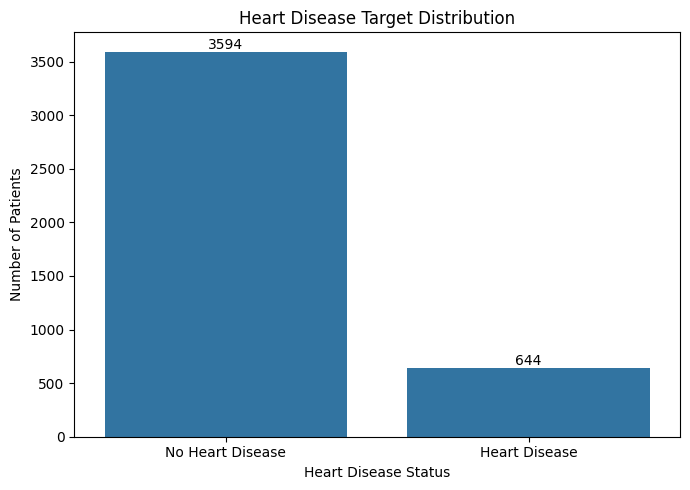

In [2]:
target_labels = {
    0: "No Heart Disease",
    1: "Heart Disease"
}

target_counts = (
    df["heart_disease"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_counts / len(df) * 100
).round(2)

target_summary = pd.DataFrame({
    "Status": [
        target_labels[value]
        for value in target_counts.index
    ],
    "Count": target_counts.values,
    "Percentage": target_percentages.values
})

display(target_summary)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="heart_disease",
    order=[0, 1]
)

ax.set_title("Heart Disease Target Distribution")
ax.set_xlabel("Heart Disease Status")
ax.set_ylabel("Number of Patients")
ax.set_xticks([0, 1])
ax.set_xticklabels([
    "No Heart Disease",
    "Heart Disease"
])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

,Feature,Missing Values,Mean,Median,Skewness
0,age,0,49.58,49.0,0.23
1,cigarettes_per_day,29,9.00,0.0,1.25
2,total_cholesterol,50,236.72,234.0,0.87
3,systolic_bp,0,132.35,128.0,1.15
4,diastolic_bp,0,82.89,82.0,0.71
5,bmi,19,25.80,25.4,0.98
6,heart_rate,1,75.88,75.0,0.64
7,glucose,388,81.97,78.0,6.21


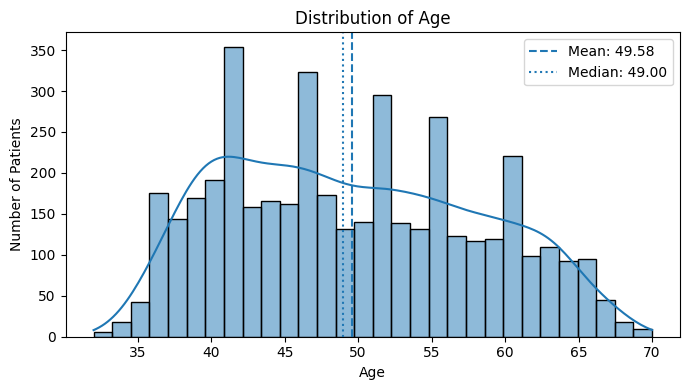

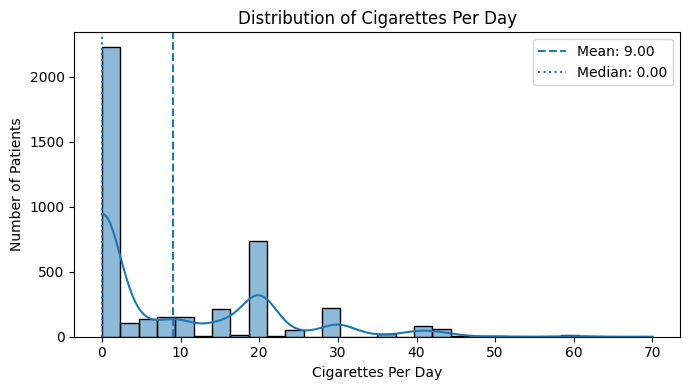

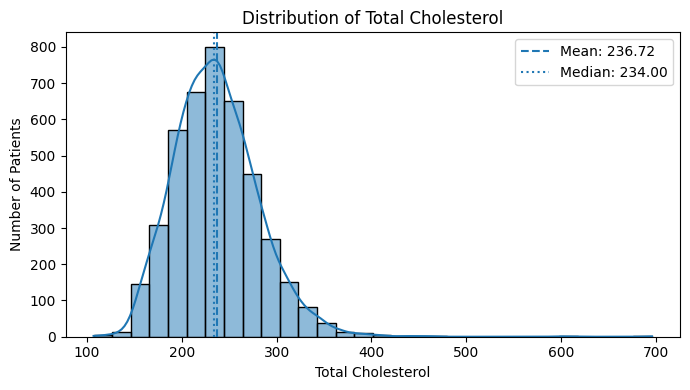

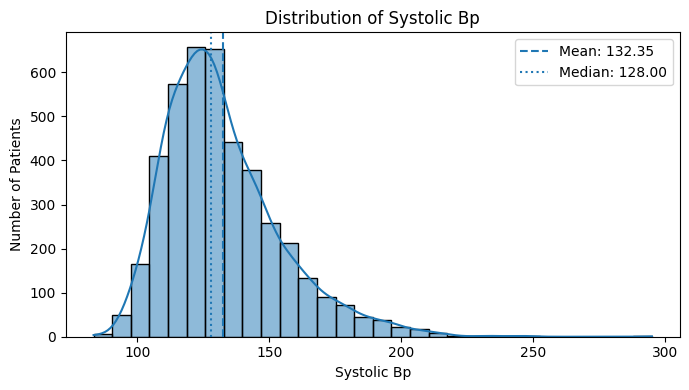

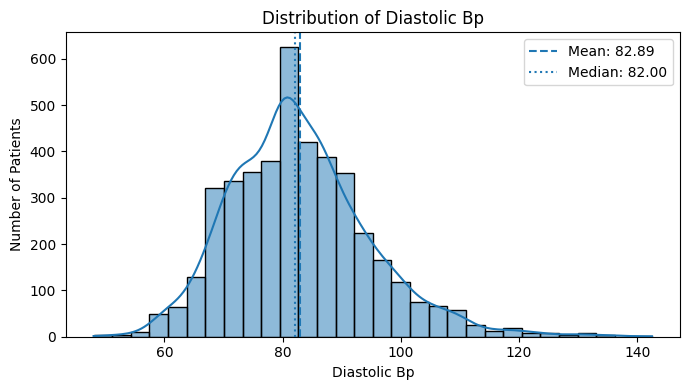

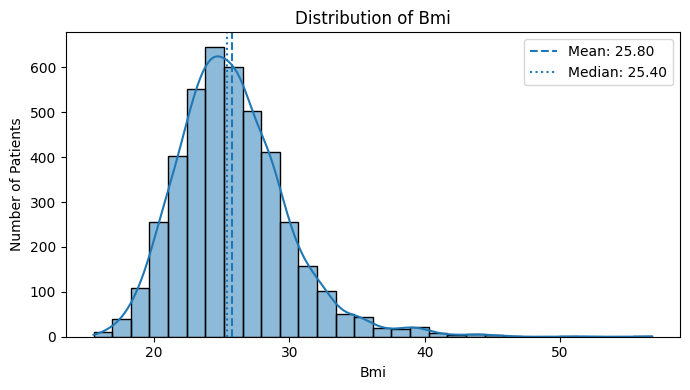

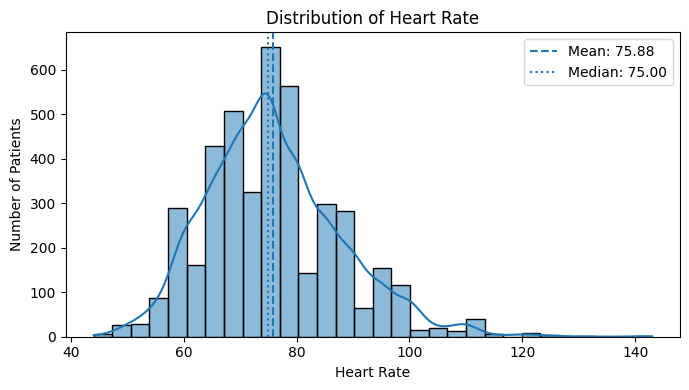

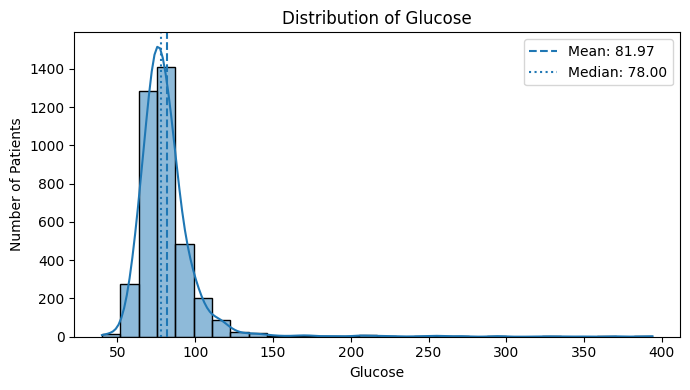

In [3]:
continuous_columns = [
    "age",
    "cigarettes_per_day",
    "total_cholesterol",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate",
    "glucose"
]

distribution_summary = pd.DataFrame({
    "Feature": continuous_columns,
    "Missing Values": [
        int(df[column].isna().sum())
        for column in continuous_columns
    ],
    "Mean": [
        round(df[column].mean(), 2)
        for column in continuous_columns
    ],
    "Median": [
        round(df[column].median(), 2)
        for column in continuous_columns
    ],
    "Skewness": [
        round(df[column].skew(), 2)
        for column in continuous_columns
    ]
})

display(distribution_summary)

for column in continuous_columns:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.axvline(
        df[column].mean(),
        linestyle="--",
        label=f"Mean: {df[column].mean():.2f}"
    )

    plt.axvline(
        df[column].median(),
        linestyle=":",
        label=f"Median: {df[column].median():.2f}"
    )

    plt.title(
        f"Distribution of {column.replace('_', ' ').title()}"
    )
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Number of Patients")
    plt.legend()
    plt.tight_layout()
    plt.show()

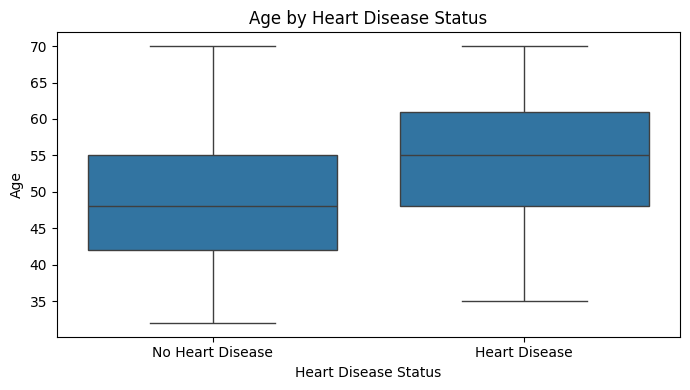

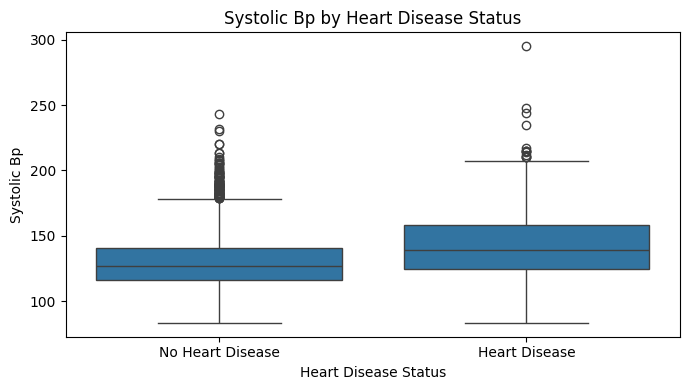

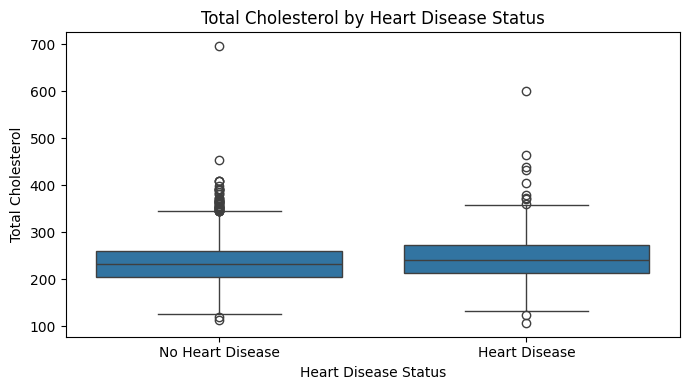

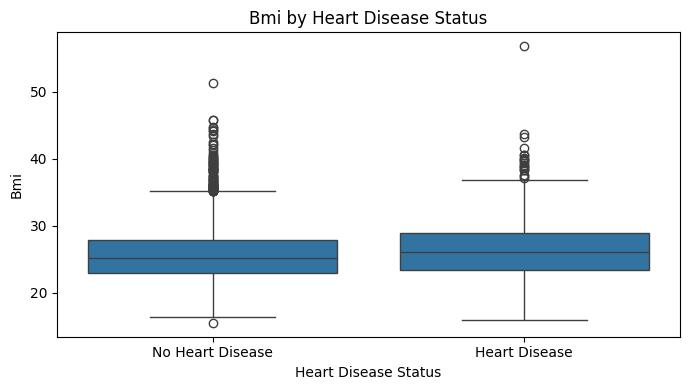

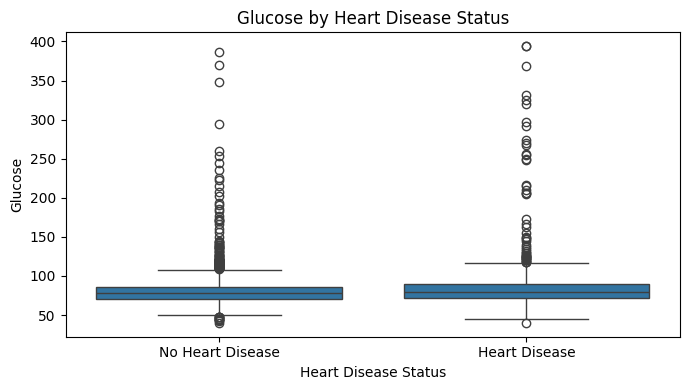

In [4]:
comparison_columns = [
    "age",
    "systolic_bp",
    "total_cholesterol",
    "bmi",
    "glucose"
]

for column in comparison_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="heart_disease",
        y=column
    )

    plt.title(
        f"{column.replace('_', ' ').title()} by Heart Disease Status"
    )
    plt.xlabel("Heart Disease Status")
    plt.ylabel(column.replace("_", " ").title())

    plt.xticks(
        ticks=[0, 1],
        labels=["No Heart Disease", "Heart Disease"]
    )

    plt.tight_layout()
    plt.show()

,gender,total_patients,heart_disease_cases,heart_disease_rate
0,female,2419,301,12.44
1,male,1819,343,18.86


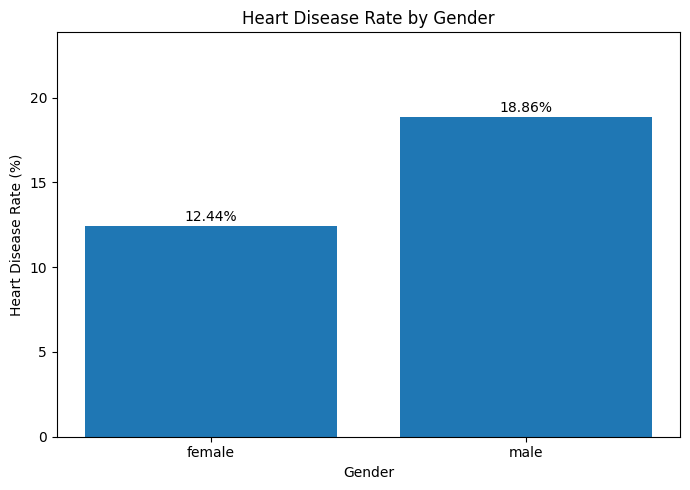

In [5]:
gender_analysis = (
    df.groupby("gender", dropna=False)["heart_disease"]
    .agg(
        total_patients="count",
        heart_disease_cases="sum"
    )
    .reset_index()
)

gender_analysis["heart_disease_rate"] = (
    gender_analysis["heart_disease_cases"]
    / gender_analysis["total_patients"]
    * 100
).round(2)

display(gender_analysis)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_analysis["gender"],
    gender_analysis["heart_disease_rate"]
)

plt.title("Heart Disease Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Heart Disease Rate (%)")

plt.ylim(
    0,
    gender_analysis["heart_disease_rate"].max() + 5
)

for bar, rate in zip(
    bars,
    gender_analysis["heart_disease_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()